# Procedural MiniGrid exploration rooms

This notebook validates and visualizes `ProceduralRoomsEnv`. Hidden environment state is used only for generator tests and visualization. The mapper and any future learning agent continue to receive only MiniGrid's partial observation.

In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

from utils.minigrid_mapper import PersistentMiniGridMapper
from utils.procedural_rooms_env import ENVIRONMENT_ID

## Configurable generator

The registered environment accepts `width`, `height`, `min_rooms`, `max_rooms`, `min_room_size`, `max_steps`, and `doorway_width` through `gym.make`.

In [2]:
env = gym.make(
    ENVIRONMENT_ID,
    width=19,
    height=19,
    min_rooms=4,
    max_rooms=6,
    min_room_size=5,
    doorway_width=1,
)
observation, info = env.reset(seed=123)

print("Environment ID:", ENVIRONMENT_ID)
print("Observation image shape:", observation["image"].shape)
print("Action space:", env.action_space)
print("Mission:", observation["mission"])
print("Rooms:", env.unwrapped.number_of_rooms)
print("Room bounds:", [r.bounds for r in env.unwrapped.room_rectangles])
print("Doorway gaps:", env.unwrapped.doorway_positions)
print("Traversable cells:", env.unwrapped.total_traversable_cells)

env.close()

Environment ID: MiniGrid-ProceduralRooms-v0
Observation image shape: (7, 7, 3)
Action space: Discrete(7)
Mission: explore the environment
Rooms: 4
Room bounds: [(1, 11, 7, 18), (8, 11, 18, 18), (1, 1, 7, 10), (8, 1, 18, 10)]
Doorway gaps: ((1, 10), (7, 12), (7, 4))
Traversable cells: 259


## Automated validation over 100 seeds

The checks cover connected free space, valid random starts, forbidden-object absence, reproducibility, diversity, zero external reward, time-limit-only termination, and compatibility with the existing mapper.

In [3]:
validation_seeds = range(100)
forbidden_objects = {"key", "door", "goal", "lava", "ball", "box"}
layout_signatures = set()
mapper_observations_checked = 0


def layout_signature(unwrapped_env):
    """Capture layout and pose for deterministic reset checks."""
    grid_encoding = tuple(
        None if cell is None else tuple(map(int, cell.encode()))
        for cell in unwrapped_env.grid.grid
    )
    return (
        grid_encoding,
        tuple(map(int, unwrapped_env.agent_pos)),
        int(unwrapped_env.agent_dir),
        tuple(room.bounds for room in unwrapped_env.room_rectangles),
        tuple(unwrapped_env.doorway_positions),
    )


for seed in validation_seeds:
    validation_env = gym.make(ENVIRONMENT_ID)
    observation, info = validation_env.reset(seed=seed)
    unwrapped_env = validation_env.unwrapped

    assert unwrapped_env.validate_connectivity()
    assert (
        unwrapped_env.min_rooms
        <= unwrapped_env.number_of_rooms
        <= unwrapped_env.max_rooms
    )
    assert unwrapped_env.grid.get(*unwrapped_env.agent_pos) is None
    assert validation_env.action_space.n == 7

    object_types = {
        cell.type
        for cell in unwrapped_env.grid.grid
        if cell is not None
    }
    assert object_types.isdisjoint(forbidden_objects)
    assert object_types == {"wall"}

    first_signature = layout_signature(unwrapped_env)
    observation_again, info = validation_env.reset(seed=seed)
    assert layout_signature(validation_env.unwrapped) == first_signature
    layout_signatures.add(first_signature[0])

    mapper = PersistentMiniGridMapper()
    mapper.reset(observation_again)
    validation_env.action_space.seed(100_000 + seed)

    for _ in range(10):
        action = validation_env.action_space.sample()
        mapper.predict_action(action)
        observation_again, reward, terminated, truncated, info = (
            validation_env.step(action)
        )
        mapper.observe(observation_again)
        assert reward == 0.0
        assert not terminated
        mapper_observations_checked += 1

    validation_env.close()

assert len(layout_signatures) > 1

print("Procedural environment validation passed.")
print("Seeds validated:", len(validation_seeds))
print("Unique layouts:", len(layout_signatures))
print("Mapper observations checked:", mapper_observations_checked)
print("Connectivity failures: 0")
print("Forbidden-object violations: 0")
print("Reproducibility failures: 0")

Procedural environment validation passed.
Seeds validated: 100
Unique layouts: 100
Mapper observations checked: 1000
Connectivity failures: 0
Forbidden-object violations: 0
Reproducibility failures: 0


## Six example layouts

These full-map renders are for generator inspection only. A learning agent does not receive them.

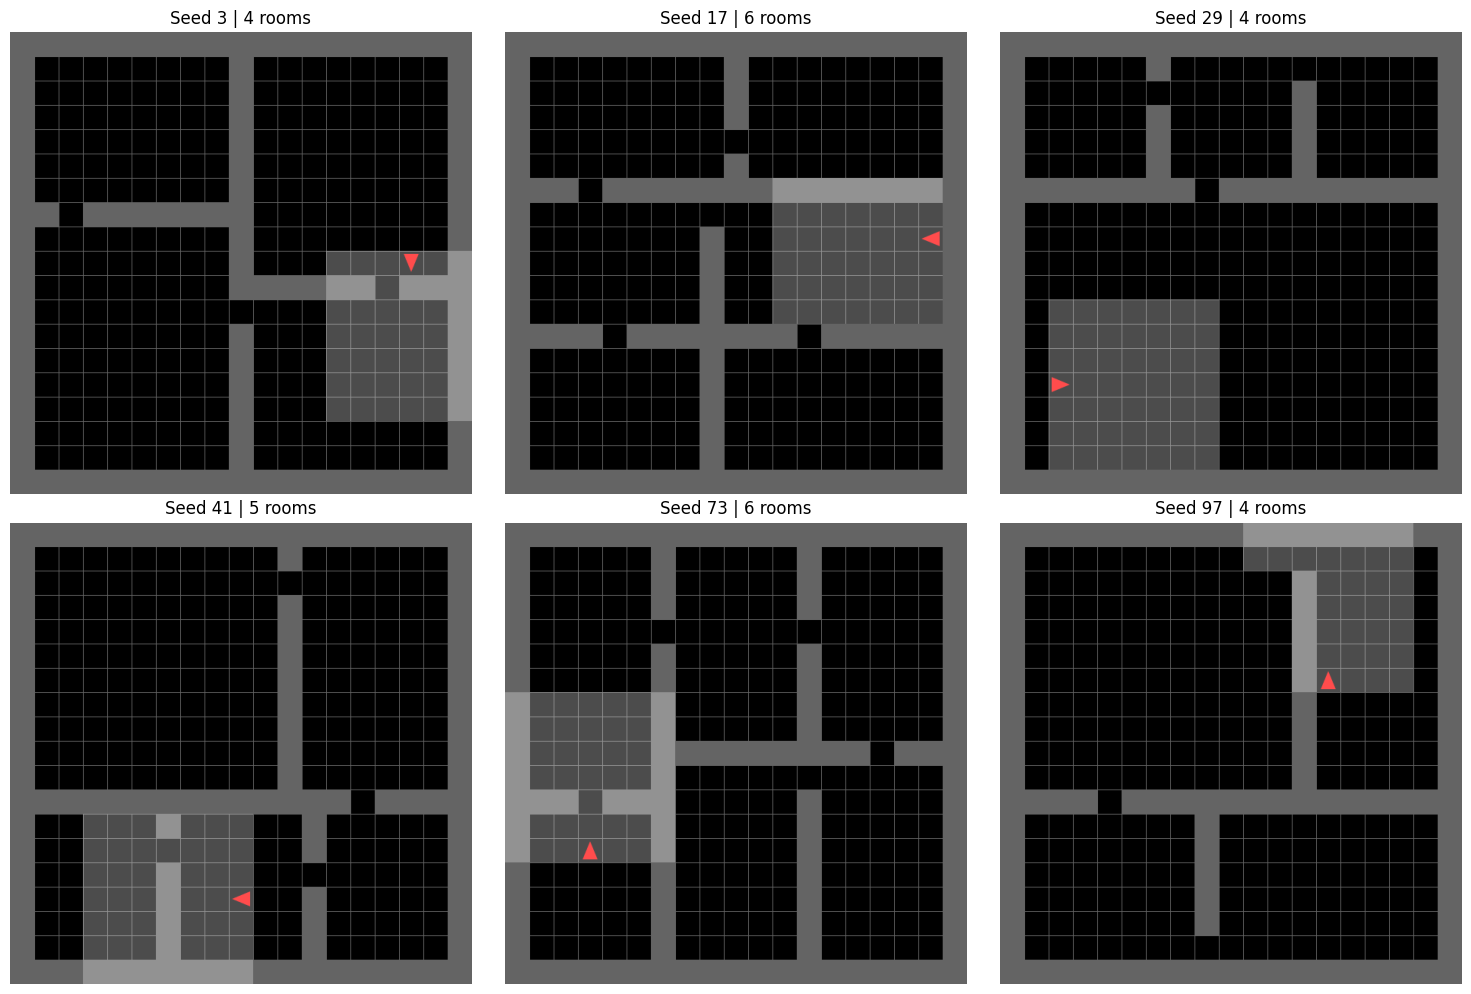

In [4]:
example_seeds = [3, 17, 29, 41, 73, 97]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for axis, seed in zip(axes.flat, example_seeds):
    example_env = gym.make(ENVIRONMENT_ID, render_mode="rgb_array")
    observation, info = example_env.reset(seed=seed)
    image = example_env.render()

    axis.imshow(image)
    axis.set_title(
        f"Seed {seed} | {example_env.unwrapped.number_of_rooms} rooms"
    )
    axis.axis("off")
    example_env.close()

plt.tight_layout()
plt.show()

## Random exploration with persistent ASCII maps

Only `left`, `right`, and `forward` are sampled. Intrinsic reward remains outside the environment and is computed exclusively from `MappingUpdate.new_cells`.

In [5]:
exploration_beta = 1.0
random_exploration_seeds = [201, 202, 203, 204, 205, 206]
random_exploration_steps = 400
random_results = []

for seed in random_exploration_seeds:
    exploration_env = gym.make(
        ENVIRONMENT_ID, max_steps=random_exploration_steps
    )
    observation, info = exploration_env.reset(seed=seed)
    mapper = PersistentMiniGridMapper()

    # Initial discoveries establish knowledge but earn no reward.
    mapper.reset(observation)
    initial_known_cells = len(mapper.cells)
    action_rng = np.random.default_rng(seed)
    cumulative_intrinsic_reward = 0.0
    steps = 0
    terminated = False
    truncated = False

    while not (terminated or truncated):
        action = int(action_rng.integers(0, 3))
        mapper.predict_action(action)
        observation, env_reward, terminated, truncated, info = (
            exploration_env.step(action)
        )
        update = mapper.observe(observation)
        cumulative_intrinsic_reward += (
            exploration_beta * update.new_cells
        )
        steps += 1

    map_cell_count = exploration_env.unwrapped.width * exploration_env.unwrapped.height
    coverage = len(mapper.cells) / map_cell_count
    random_results.append(
        {
            "seed": seed,
            "steps": steps,
            "initial_known_cells": initial_known_cells,
            "final_known_cells": len(mapper.cells),
            "coverage": coverage,
            "intrinsic_reward": cumulative_intrinsic_reward,
        }
    )

    print(
        f"Seed {seed} | steps={steps} | coverage={coverage:.1%} | "
        f"intrinsic reward={cumulative_intrinsic_reward:.1f}"
    )
    print(mapper.render_ascii(padding=0))
    print()
    exploration_env.close()

print(
    "Average random final coverage:",
    f"{np.mean([result['coverage'] for result in random_results]):.1%}",
)

Seed 201 | steps=400 | coverage=56.0% | intrinsic reward=153.0
????FFFFFFF????
???F.......FF??
???FF.......F??
?????#.########
?????#........#
?????#........#
?FFF?#........#
F..F?#........#
F..F?#........#
###.##........#
F....#........#
F....#........#
F.............#
F....#....^...#
F....#........#
?##############

Seed 202 | steps=400 | coverage=56.2% | intrinsic reward=154.0
#########?????
#.......#?????
#.......#FFFFF
#.......#....F
#.......#....F
#.......#....F
#.......#....F
#.....^.#....F
#............F
#.......#....F
#.......##.###
##.######....F
#.......#....F
#.......#..FFF
#.....FF#FF???
#FFFFF????????

Seed 203 | steps=400 | coverage=40.2% | intrinsic reward=103.0
#FFFFF#?????
#.....#?????
#.....#?????
#.....#?????
#.....#?????
##.####?????
#.....#?????
#.....#FFFFF
#.....#....F
#.....#....F
#.....#....F
#.....#....F
#.....#....F
#..<.......F
############

Seed 204 | steps=400 | coverage=56.0% | intrinsic reward=177.0
?#######?????????
#.......FF#FFF???
#.........#..F???
